# Ableton Project Notebook

### Notebook Runtime

##### Updated 11/2024

#### Local
* should work with same python3 environment as parse_projects.py 

#### Colab:
* run `./ableton_projects/start_notebook.sh` to start
server on `8888`
* see `start_notebook.sh` for installing python2 kernel and packages
* see https://research.google.com/colaboratory/local-runtimes.html


### Modules

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import parse_projects as parser
from typing import List, Dict, Any

print(f"Python Version:\n  {parser.PYTHON_VERSION}")


Python Version:
  3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


### Load Parsed Projects

In [60]:
#@title Get info for all Projects and cache

# Load projects using default args should work if notebook is in project dir.
load_most_recent_cached = True #@param {type:"boolean"}
project_dir = "./" #@param {type:"string"}
# Overwrite parser defaults
# SKIP_FOLDERS = [ 'Backup', 'old', 'Samples', 'Ableton Project Info', '.git'] #@param {type:"raw"}
# CACHE_DIR = "./logs/" #@param {type:"string"}


# Load from recent cache (fast)
if load_most_recent_cached: 
  project_info = parser.load_info(prefix=parser.CACHE_INFO_FILE, load_most_recent=True)
  project_counters = parser.load_dict_from_json(parser.COUNTER_JSON)
  project_df = parser.load_project_df_from_tsv(parser.PROJECT_TSV)

# Parse project .als files
else:
  project_info, project_counters, project_df = parser.run_parser(project_dir)


Loading project_info from 2024-11-29 23:09:06.
Loaded 466 project_info in 0.01 seconds.
Loading json: logs/counters.json.
Loading tsv: projects.tsv.


# Analysis

### TODO
* make a 11 version for all 12, rename 12 to have 12 in name, or remove if not adding value
  * See code below for 12 projects
* reduce Au usage as much as possible, prefer vst or vst3 (not sure if code supports vst3 but neutron au can be a vst3)
  * See code below for start on AUs
* archive a10 projects that have working a11 copy,
* archive other copies to Backup folder, ideally one copy per project (or more for variations track vs dj)

In [61]:
n_recent = 5
print(f"{n_recent} most recently modified projects")
project_df.sort_values('modified').tail(n_recent)

5 most recently modified projects


,path,ableton_version_full,file_size_mb,created,modified,num_tracks,ableton_version,creation_year,last_modified_year,track_types,device_types,plugins_vst,plugins_au
name,,,,,,,,,,,,,
raw outdoor porch,./____guitarbeet\mac_work\raw outdoor porch Pr...,12.0_12049,0.01,2024-06-05 10:08:40,2024-06-05 10:08:40,3,12,2024,2024,"AudioTrack, ReturnTrack","Reverb, Delay",NaN,NaN
dimensions and space 24,./___Dimensions_\__dimensions Project\dimensio...,11.0_11300,0.04,2024-02-17 14:35:07,2024-08-27 20:35:55,8,11,2024,2024,"AudioTrack, MasterTrack","PluginDevice, AudioEffectGroupDevice",iZotope Ozone 5,NaN
lekato loops,./lekato loops Project\lekato loops.als,12.0_12120,0.13,2024-10-27 21:06:19,2024-11-03 22:21:58,7,12,2024,2024,"AudioTrack, MidiTrack",StereoGain,NaN,NaN
DJ4 live8 V01,./z__templates\DJ4 live8 V01 Project\DJ4 live8...,11.0_11300,0.05,2022-02-04 20:33:21,2024-11-17 23:21:13,10,11,2022,2024,"AudioTrack, ReturnTrack, MasterTrack","StereoGain, AudioEffectGroupDevice, Reverb, De...",NaN,NaN
chill guitar beats lekato,./chill guitar beats lekato Project\chill guit...,12.0_12120,6.21,2024-11-03 22:23:34,2024-11-24 19:58:19,30,12,2024,2024,"AudioTrack, GroupTrack, MidiTrack","Eq8, GlueCompressor, AuPluginDevice, AutoFilter",NaN,Neutron 4


Counter: ableton_version has 3 entries


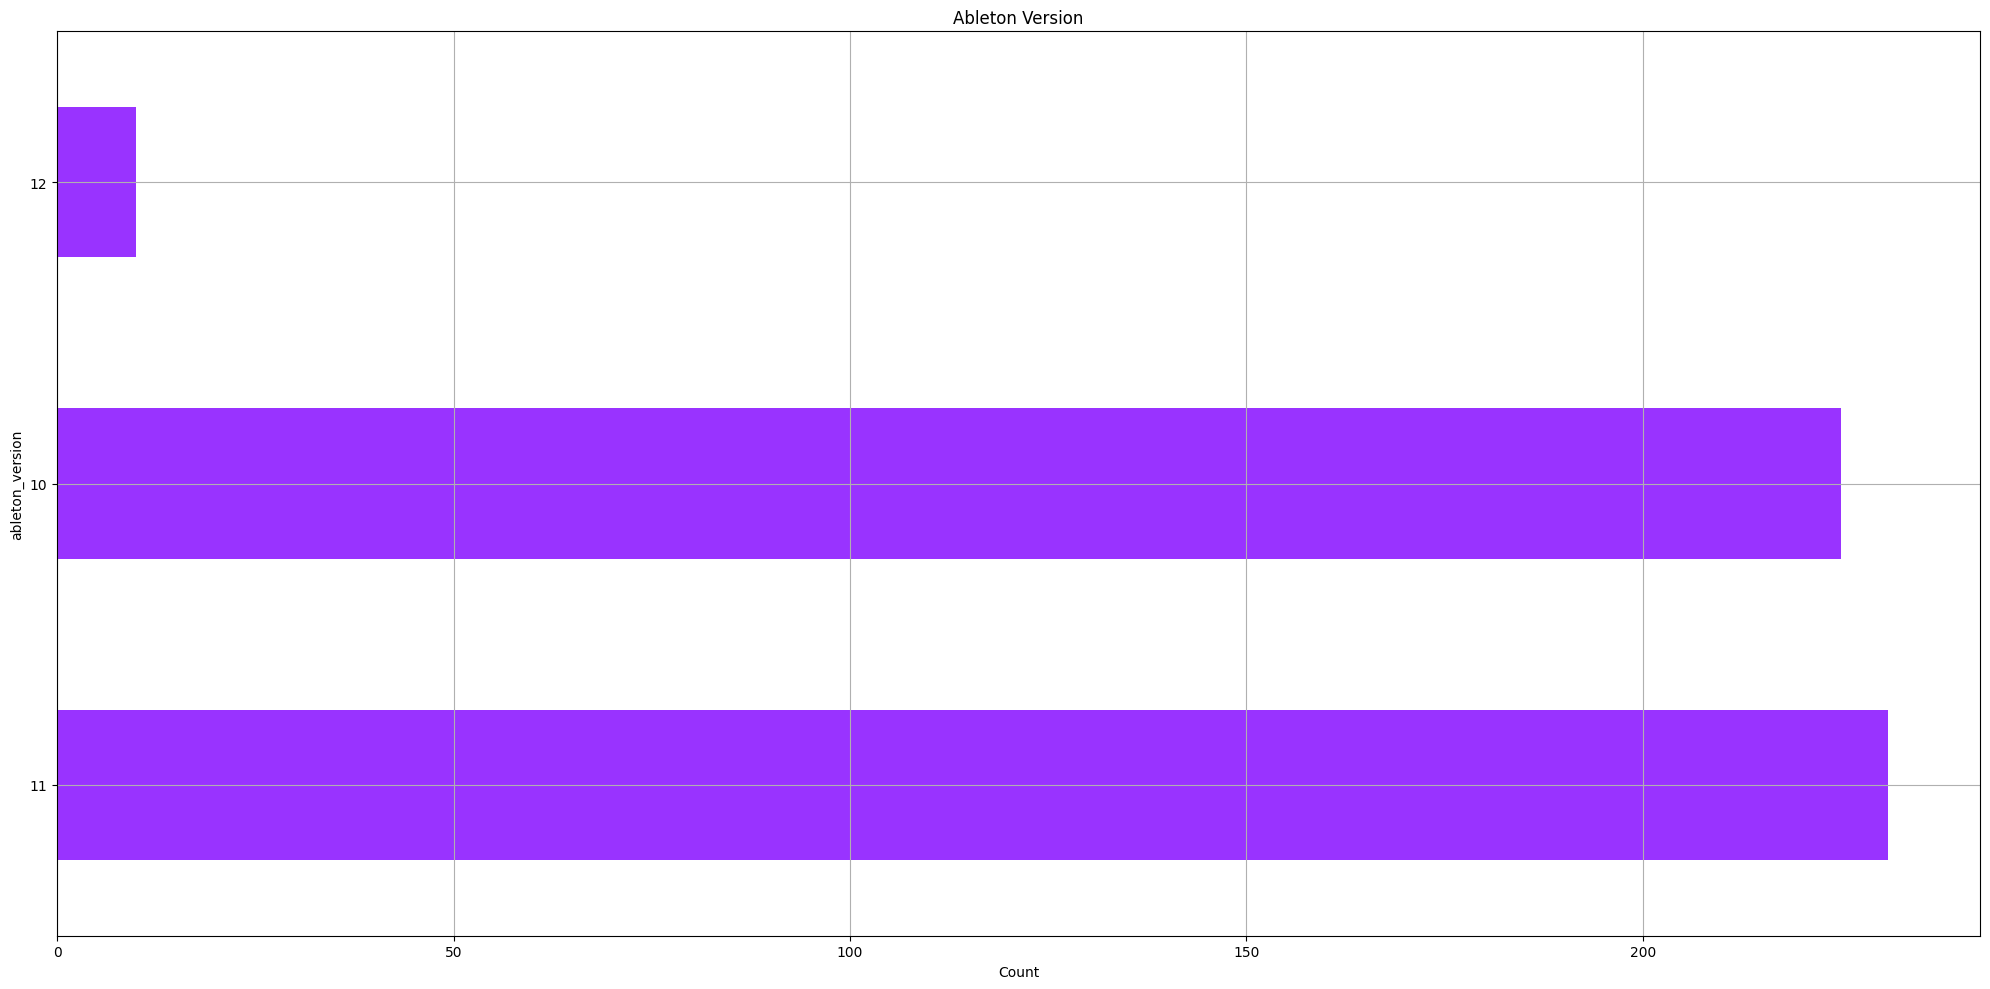

Counter: creation_year has 6 entries


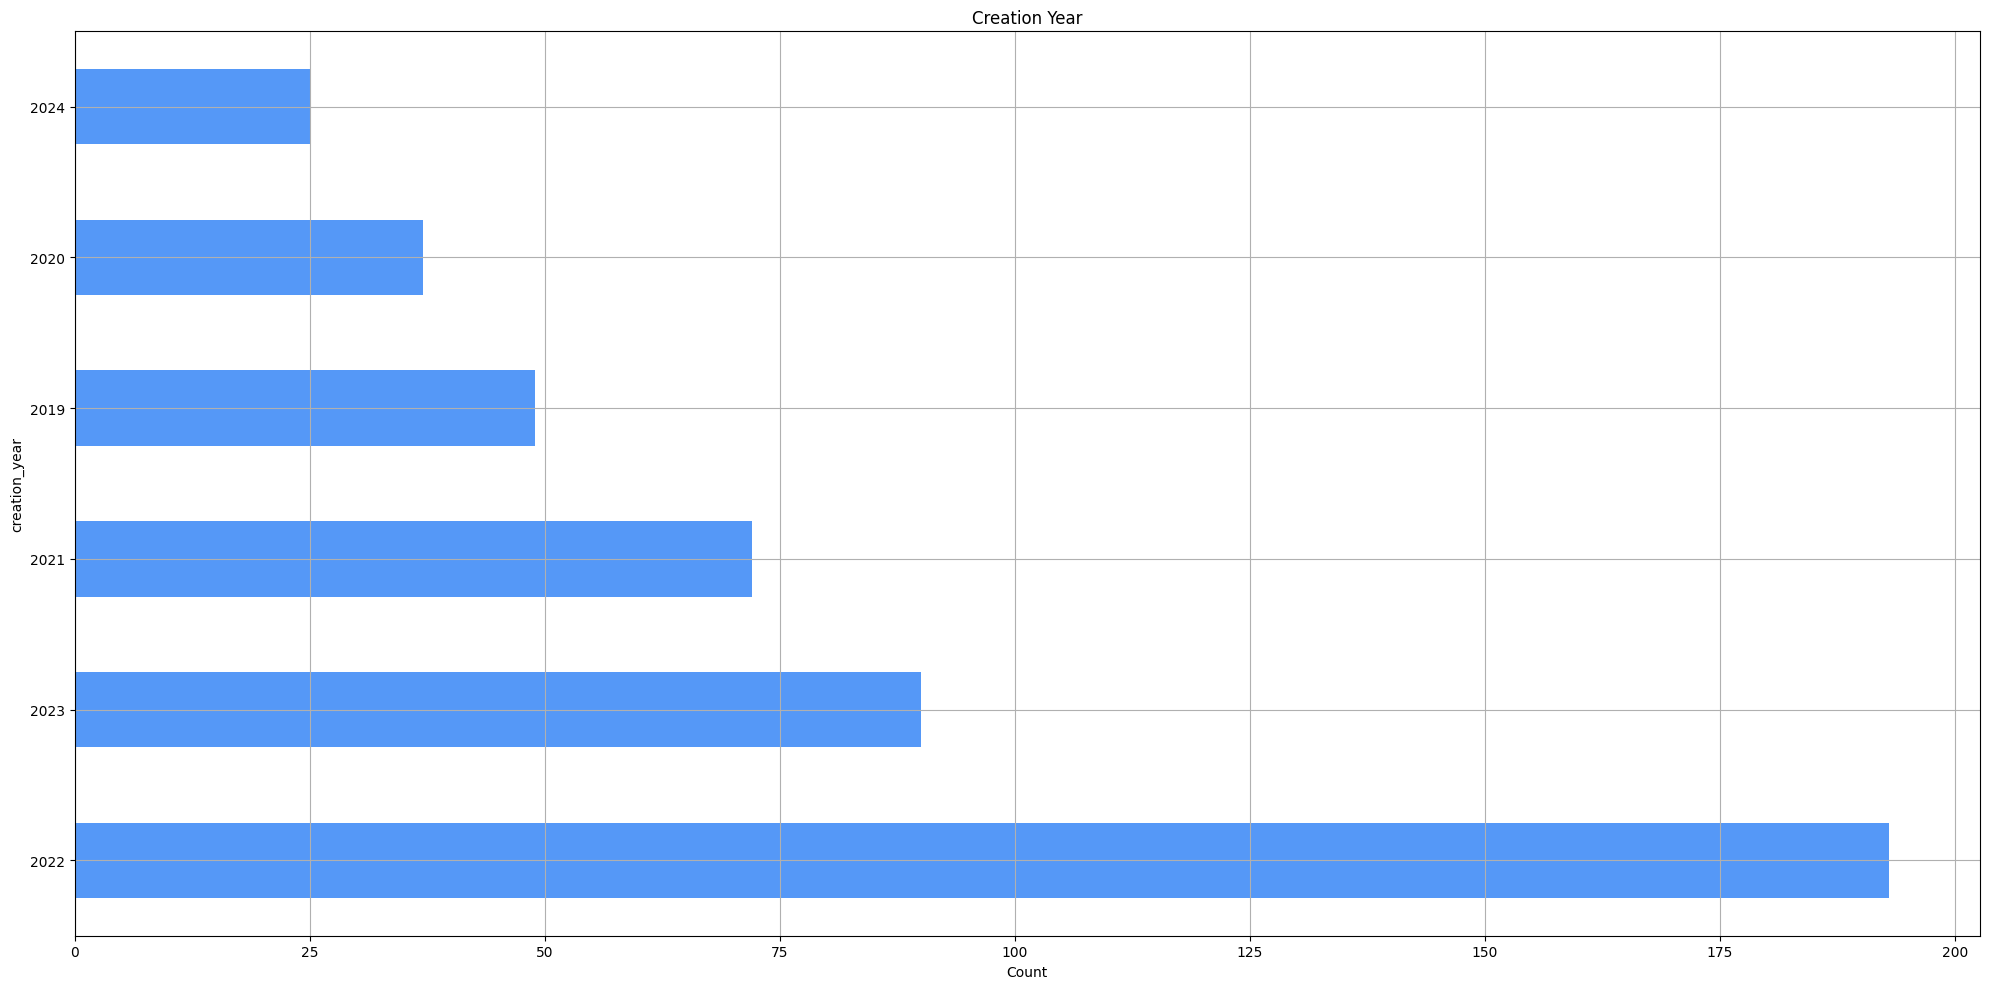

Counter: device_types has 56 entries


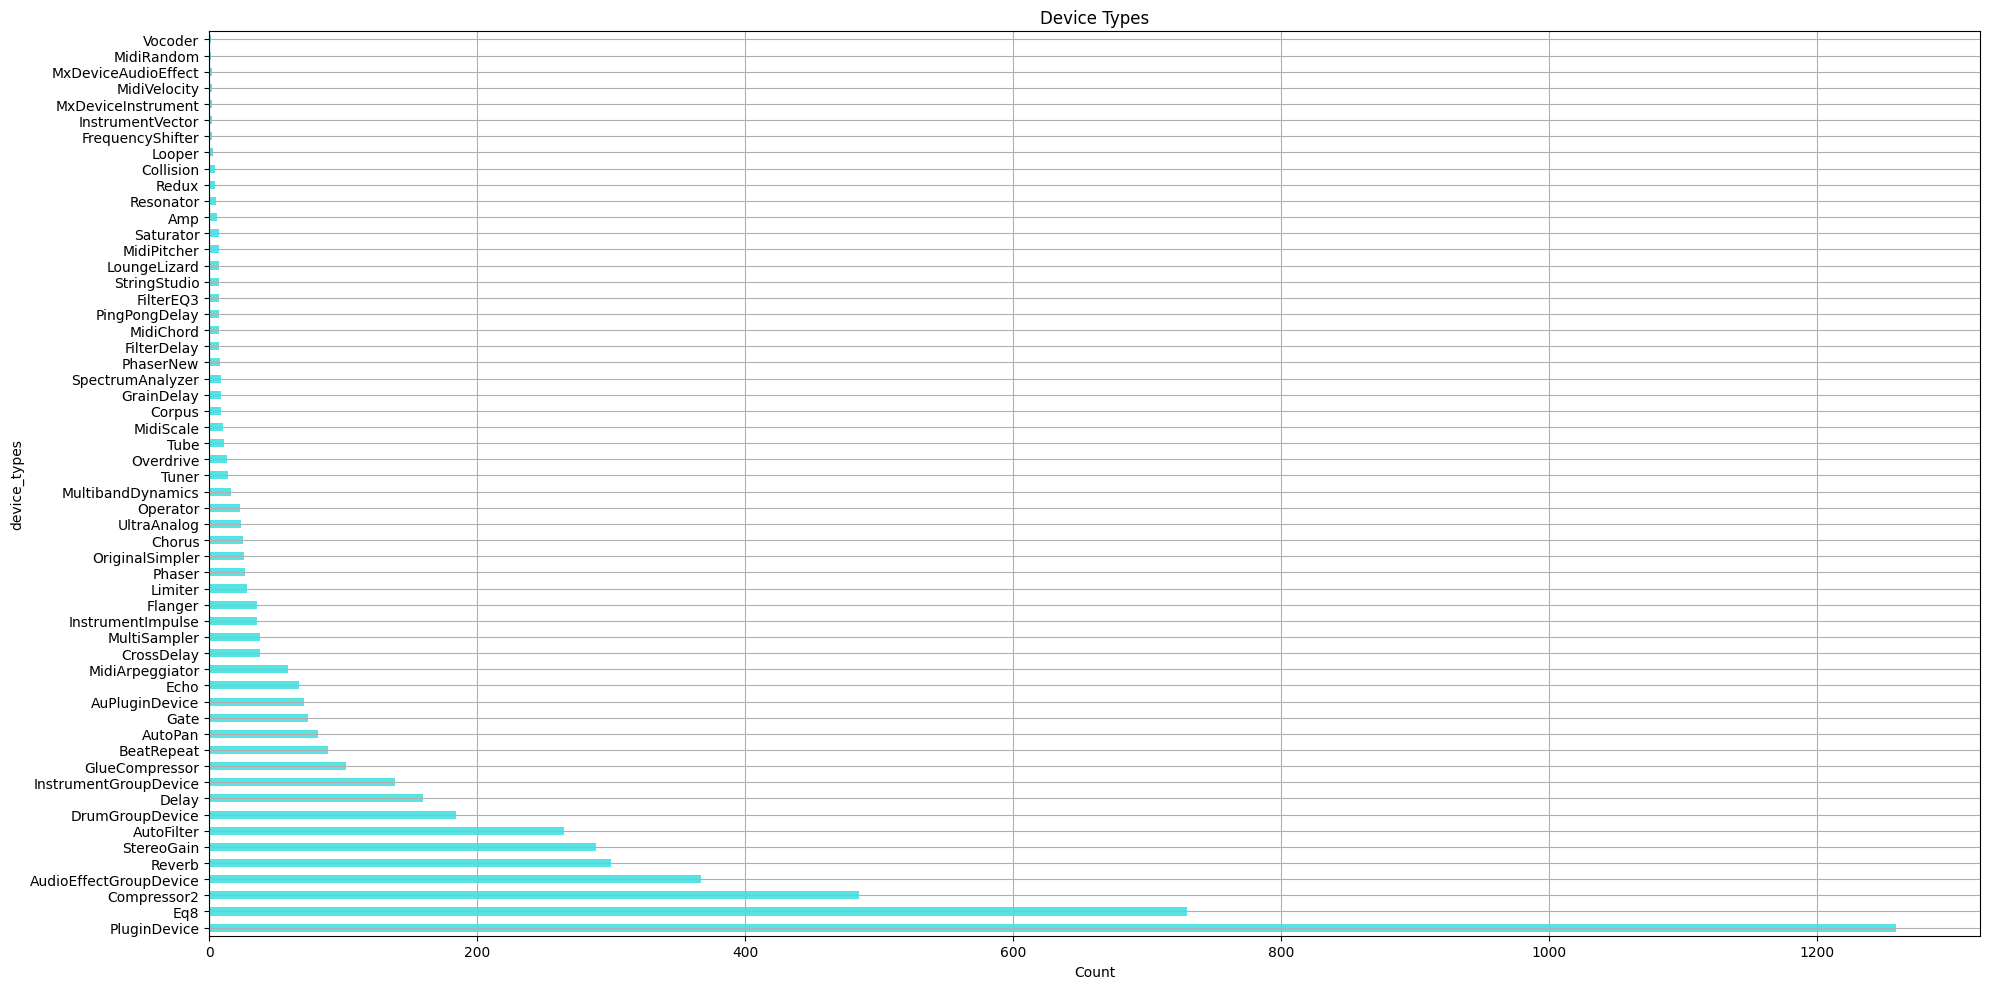

Counter: last_modified_year has 7 entries


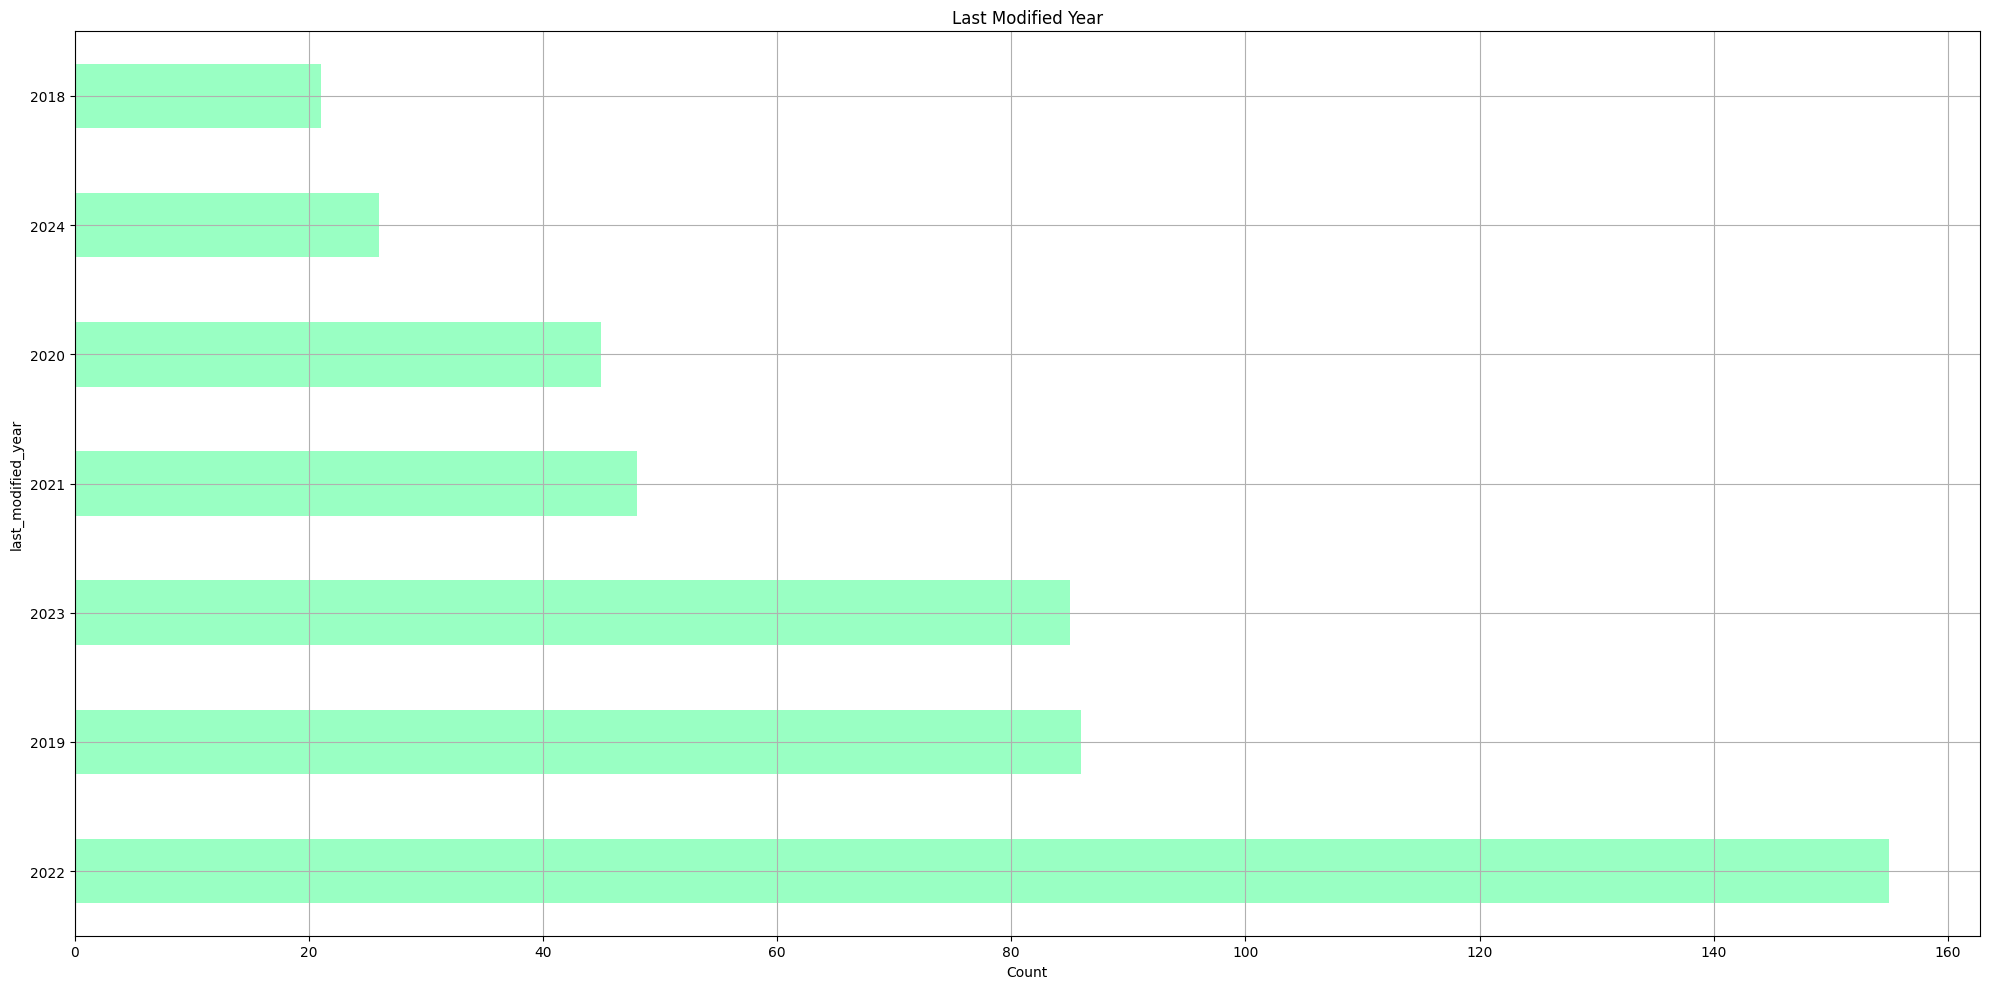

Counter: plugins_au has 8 entries


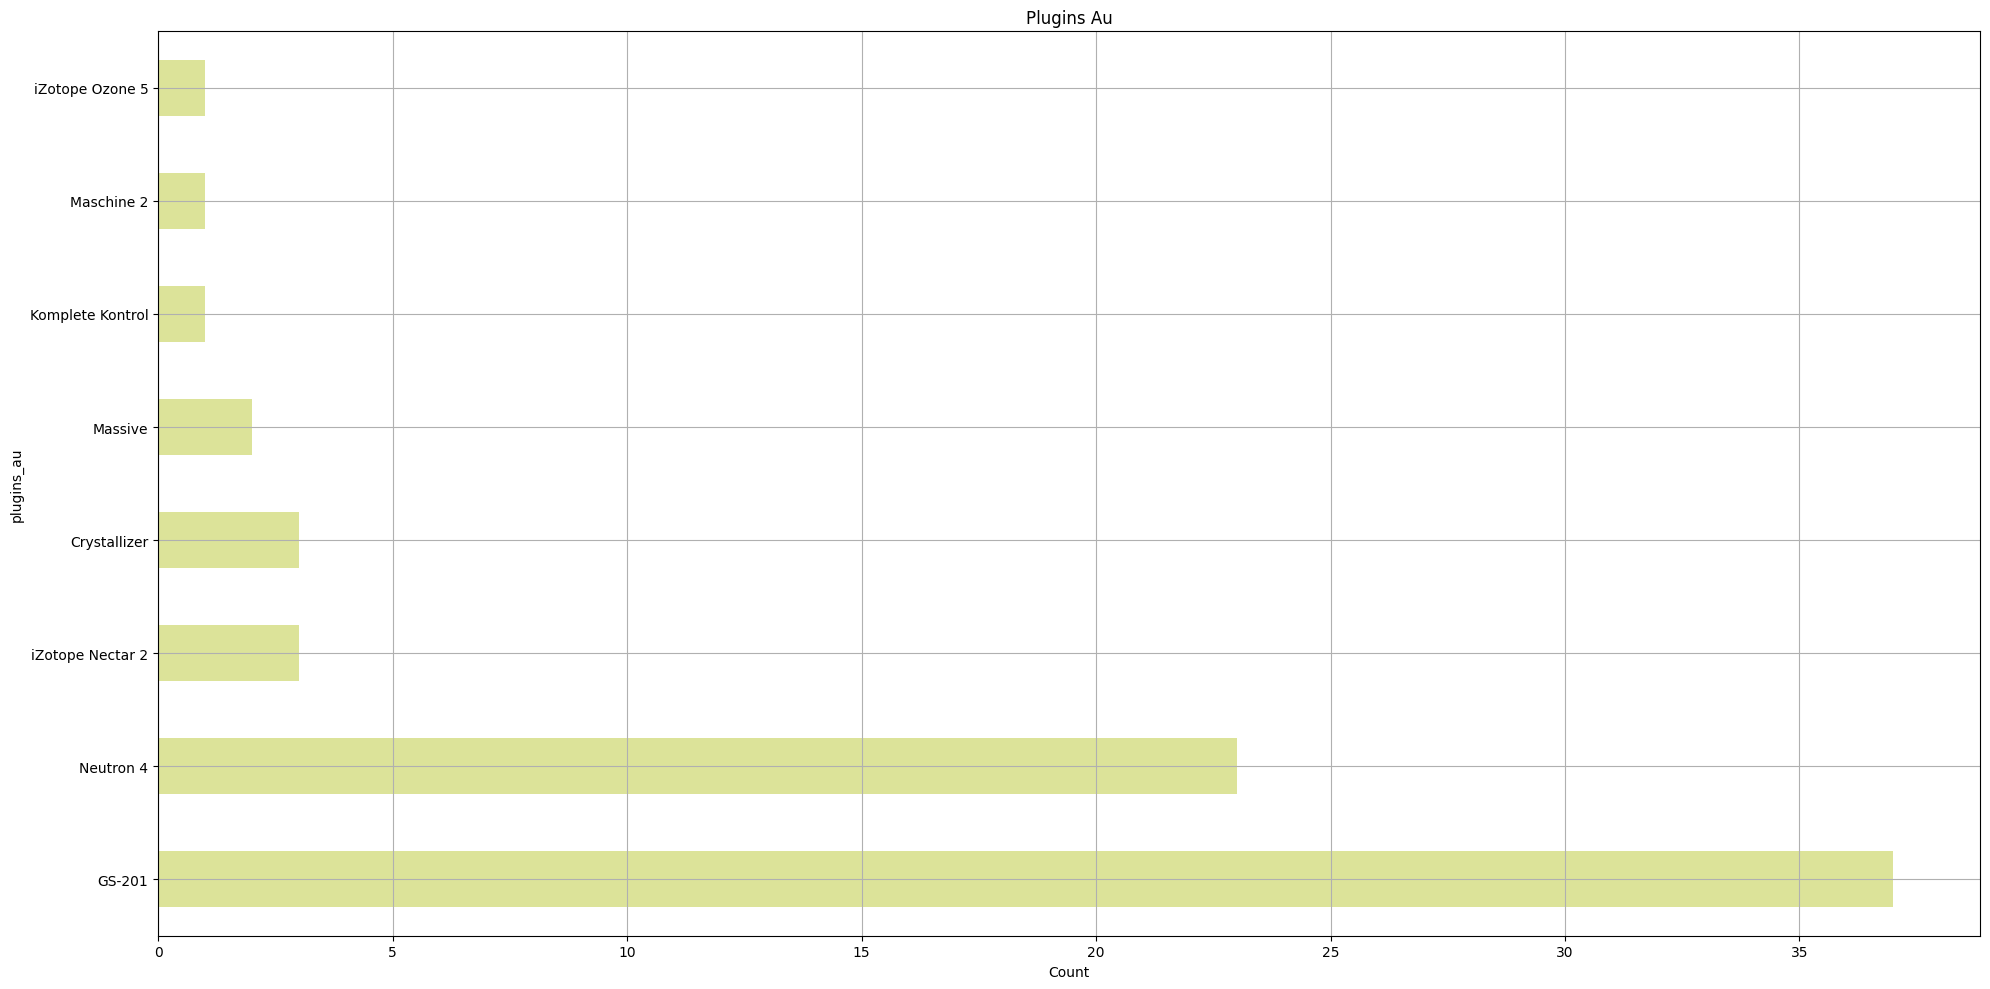

Counter: plugins_vst has 48 entries


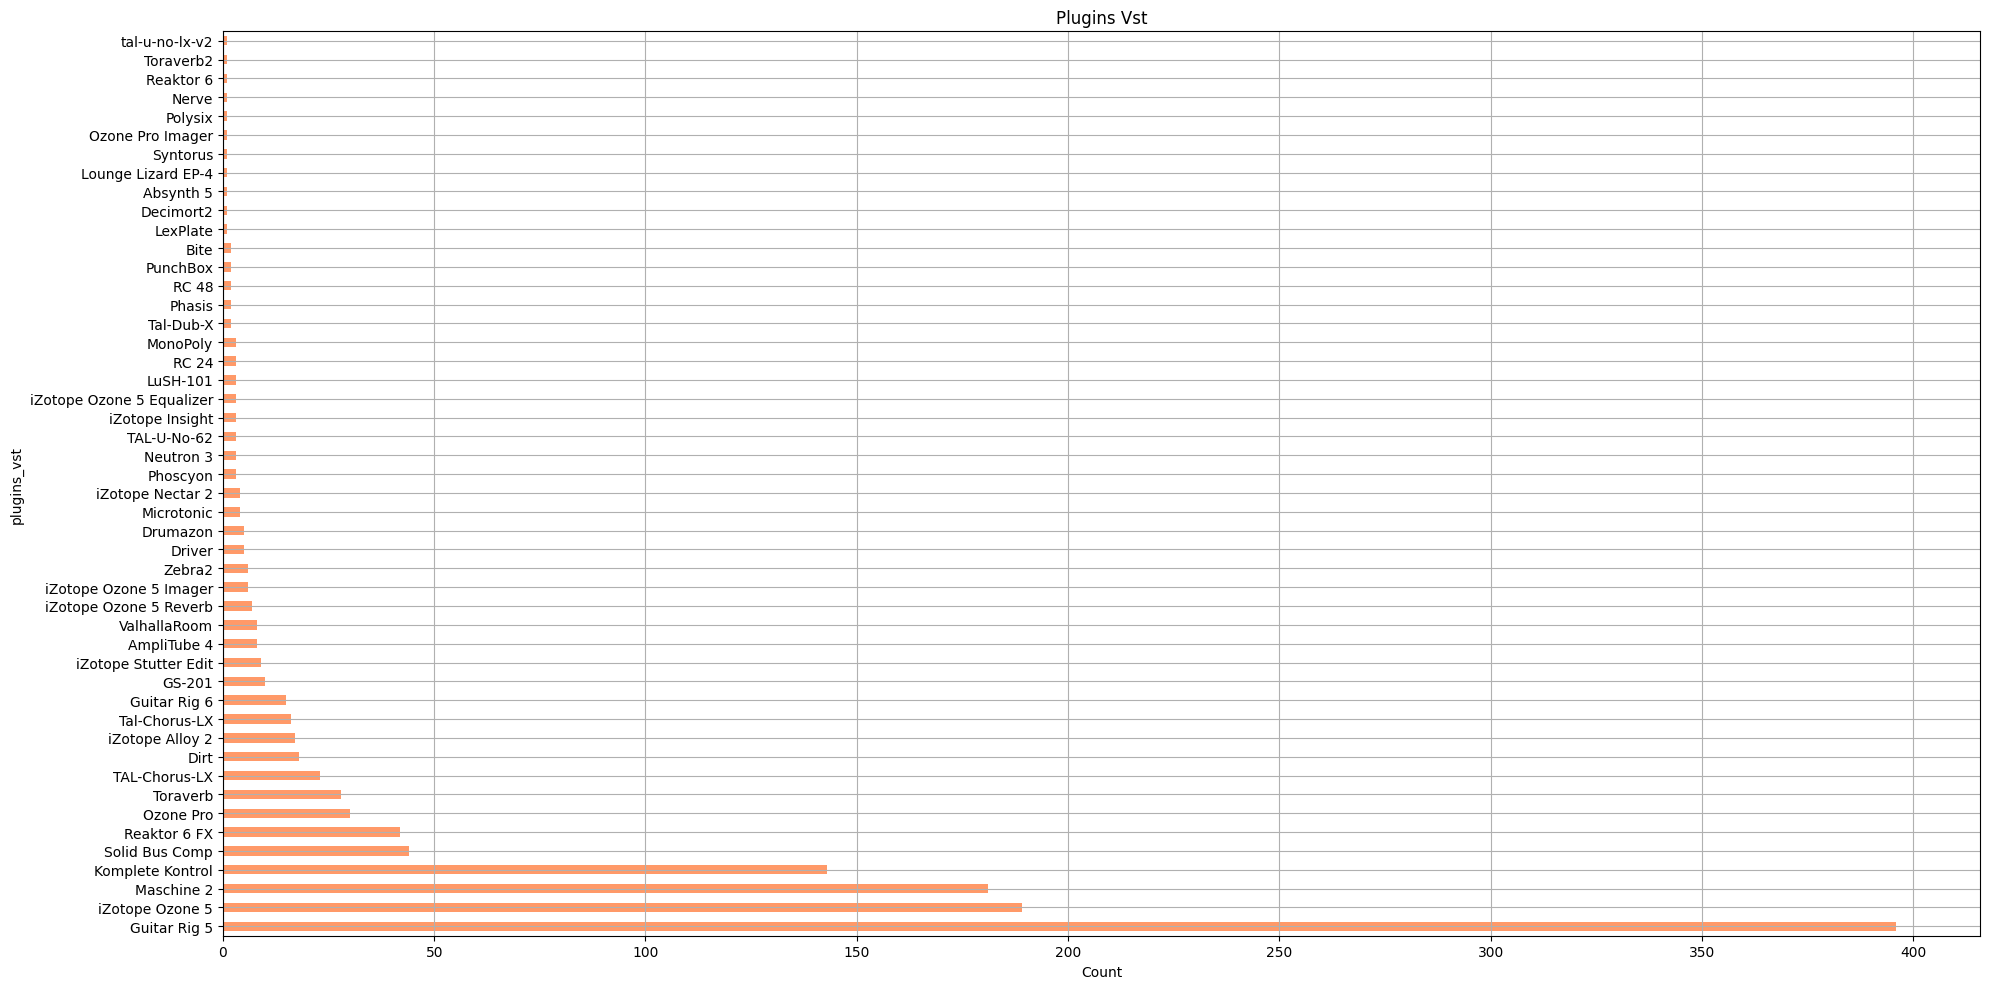

Counter: track_types has 5 entries


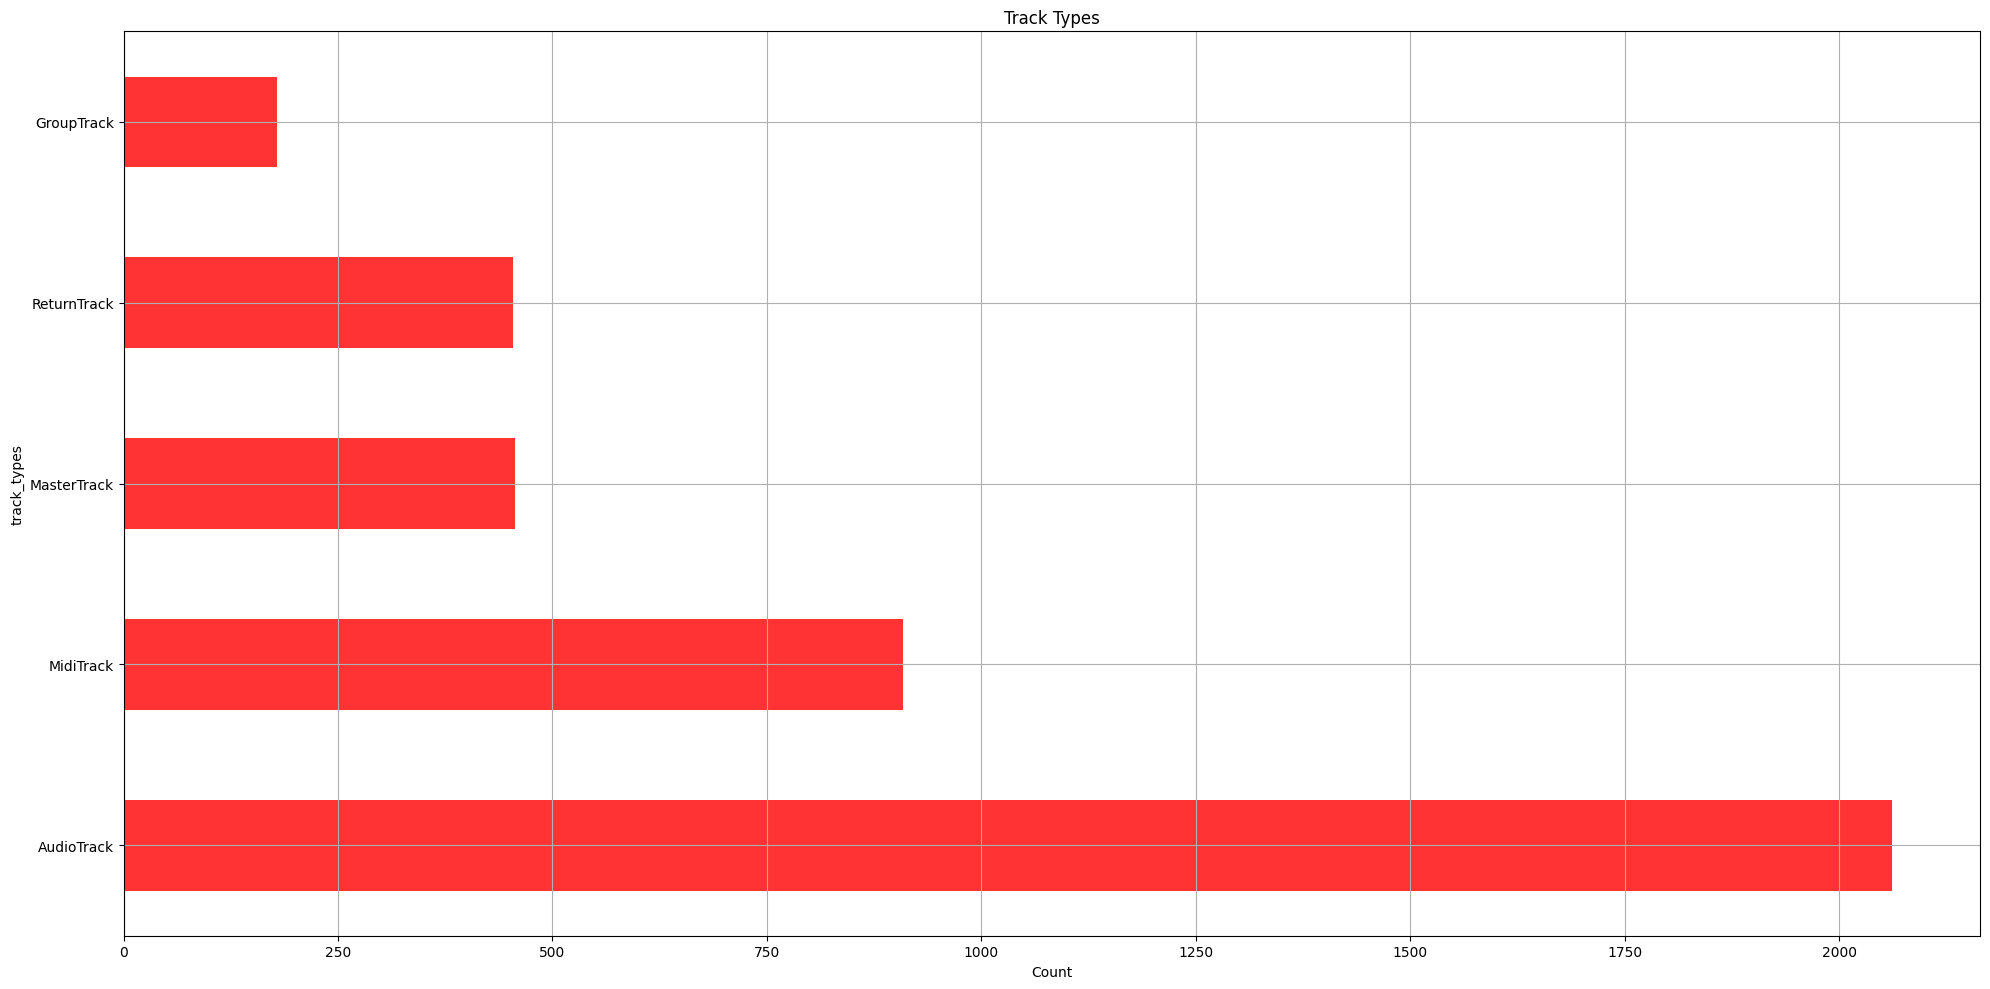

In [62]:
def plot_counters(
    counters,
    top_n=10,
    figsize=(12, 6),
    grid=True,
    alpha=0.8,
    cmap_name='rainbow',
):
  """Generates bar charts for counters, with extensive customization options."""

  num_counters = len(counters) if counters else 0
  cmap = plt.get_cmap(cmap_name, num_counters)  # Use plt.get_cmap
  bar_colors = [cmap(i) for i in range(num_counters)]

  for i, (name, counter) in enumerate(counters.items()):
    print(f'Counter: {name} has {len(counter)} entries')
    if not counter or all(v == 0 for v in counter.values()):
      print(f"WARNING: Counter '{name}' is empty or all zeros. Skipping plot.")
      continue

    df = pd.DataFrame.from_dict(
        counter, orient='index', columns=['count']
    ).sort_values('count', ascending=False)
    df = df.head(top_n)

    title = name.replace('_', ' ').title()
    if top_n:
      title += f' (Top {top_n})'

    df.plot.barh(
        y='count',
        color=[bar_colors[i]],  # Use list of a single color
        figsize=figsize,
        alpha=alpha,
        grid=grid,
        title=title,
        xlabel='Count',
        ylabel=name,
        legend=False,
    )
    plt.tight_layout()
    plt.show()


plot_counters(project_counters, top_n=None, figsize=(20, 10))


## Query Projects

In [63]:
def query_projects_by_plugin(
    project_info: Dict[str, Any], plugin_type: str, preset_name: str
) -> List[str]:
  """Finds projects that use a specific plugin and preset."""
  assert plugin_type in [
      'PluginDevice',
      'AuPluginDevice',
  ], f'Invalid plugin type: {plugin_type}'
  matching_projects = [
      f"{fname}-{track['index']}"
      for fname, v in project_info.items()
      for track in v['tracks']
      for dev in track['devices']
      if dev['type'] == plugin_type and dev['preset'] == preset_name
  ]

  print(
      f'Projects matching {plugin_type}:'
      f' {preset_name}\n{sorted(matching_projects)}'
  )
  return matching_projects



def query_projects_with_plugin_type(
    project_info: Dict[str, Any], plugin_type: str
) -> List[str]:
  """Finds projects that contain a specific plugin type."""

  assert plugin_type in [
      'PluginDevice',
      'AuPluginDevice',
  ], f'Invalid plugin type: {plugin_type}'

  projects_with_type = [
      fname
      for fname, project in project_info.items()
      if any(
          dev['type'] == plugin_type
          for track in project['tracks']
          for dev in track['devices']
      )
  ]
  print(f"Projects containing '{plugin_type}':\n{sorted(projects_with_type)}")
  return projects_with_type


au_projects = query_projects_with_plugin_type(project_info, 'AuPluginDevice')
query_projects = query_projects_by_plugin(
    project_info, 'PluginDevice', 'Neutron 3'
)


Projects containing 'AuPluginDevice':
['1', '2', '3', '4', '461', '5', 'Blazed Electric Guitar recorded', 'Dance Beat [Loops]', "Dowm Chill 'vErB up", 'Downtime Chill Vibe', 'Green the color', 'Maggots Chill', 'SpokoACIDsampler [song] [unmxd]', 'acoustic sad vox', 'b itch gowsays [Loops]', 'brady-jake jam +extra day 2', 'brady-jake jam 0', 'chill guitar beats lekato', 'dimension live remix 2', 'hazzy chill', 'high vox loops', 'jarryork', 'jarryork 23', 'loaunge chill j a10 gsi', 'lofi accoustic psych', 'new bumpabumb', 'psych guiTarr beat', 'slow burn mixdown', 'something', 'surff classicaL sh', 'trippy vox loops', 'watching fish']
Projects matching PluginDevice: Neutron 3
['_acoustic jams sorted-33', '_two track jams-31', 'house acoustic jam-1']


In [64]:
version = 12
print(f'Projects from Ableton Version: {version}')
project_df.loc[project_df['ableton_version'] == str(version)]

Projects from Ableton Version: 12


,path,ableton_version_full,file_size_mb,created,modified,num_tracks,ableton_version,creation_year,last_modified_year,track_types,device_types,plugins_vst,plugins_au
name,,,,,,,,,,,,,


In [65]:
ALLOW_AUS = ['GS-201']
print(f'Projects with banned AudioUnits: {version}')
project_df.loc[project_df['plugins_au'].notna()].loc[~project_df['plugins_au'].isin(ALLOW_AUS)]

Projects with banned AudioUnits: 12


,path,ableton_version_full,file_size_mb,created,modified,num_tracks,ableton_version,creation_year,last_modified_year,track_types,device_types,plugins_vst,plugins_au
name,,,,,,,,,,,,,
chill guitar beats lekato,./chill guitar beats lekato Project\chill guit...,12.0_12120,6.21,2024-11-03 22:23:34,2024-11-24 19:58:19,30,12,2024,2024,"AudioTrack, GroupTrack, MidiTrack","Eq8, GlueCompressor, AuPluginDevice, AutoFilter",NaN,Neutron 4
new bumpabumb,./_electronic dance house\drumbumpa bump odwal...,10.0_377,0.41,2019-09-10 00:52:09,2019-09-10 00:33:48,33,10,2019,2019,"GroupTrack, MidiTrack, AudioTrack, ReturnTrack...","AudioEffectGroupDevice, AutoFilter, Instrument...",NaN,"GS-201, Crystallizer"
slow burn mixdown,./_witch house\__witchr Project\projects\slow ...,10.0_377,0.49,2020-11-09 00:20:00,2022-11-20 02:27:16,11,10,2020,2022,"AudioTrack, MidiTrack, ReturnTrack, MasterTrack","BeatRepeat, DrumGroupDevice, AudioEffectGroupD...",Ozone Pro,"Komplete Kontrol, Maschine 2"
acoustic sad vox,./__psychy rock tracks\_psych demos Project\a...,11.0_11300,0.06,2023-10-02 00:48:58,2023-10-02 00:47:36,6,11,2023,2023,"AudioTrack, ReturnTrack, MasterTrack","PluginDevice, AuPluginDevice","Dirt, Guitar Rig 5, Solid Bus Comp",iZotope Nectar 2
3,./___Dimensions_\3 trapped in 3d Project\3.als,11.0_11202,2.07,2023-08-31 00:06:26,2023-09-01 23:59:24,37,11,2023,2023,"GroupTrack, MidiTrack, AudioTrack, ReturnTrack...","Eq8, Compressor2, PluginDevice, DrumGroupDevic...","iZotope Ozone 5, TAL-Chorus-LX, iZotope Ozone ...","GS-201, Crystallizer"
4,./___Dimensions_\4 4th dim Project\4.als,11.0_436,0.89,2021-12-02 01:25:24,2022-12-27 20:16:57,22,11,2021,2022,"GroupTrack, AudioTrack, MidiTrack, ReturnTrack...","Reverb, PluginDevice, Eq8, AuPluginDevice, Mul...","iZotope Ozone 5, TAL-Chorus-LX, iZotope Ozone ...","iZotope Ozone 5, GS-201"
brady-jake jam +extra day 2,./____lightwave\brady-jake jam Project\brady-j...,10.0_377,0.61,2021-12-06 00:13:22,2021-12-04 16:47:45,14,10,2021,2021,"MidiTrack, AudioTrack, MasterTrack","PluginDevice, Compressor2, Eq8, AuPluginDevice...","Komplete Kontrol, Guitar Rig 5, Maschine 2, Ze...",Massive
brady-jake jam 0,./____lightwave\brady-jake jam Project\brady-j...,10.0_377,0.42,2021-12-05 23:47:07,2020-11-05 22:17:18,10,10,2021,2020,"MidiTrack, AudioTrack, MasterTrack","PluginDevice, Compressor2, Eq8, AuPluginDevice...","Komplete Kontrol, Guitar Rig 5, Maschine 2",Massive


In [66]:

# Orignal TODO
# dimensions 4: on a10, swap out iZotope Ozone 5 AU for VST
# slow burn mixdown: swap out Maschine 2 and Komplete Kontrol AU for VST
# brady-jake jam +extra day 2: swap out Massive AU for VST
# brady-jake jam 0: swap out Massive AU for VST
# acoustic sad vox (multiple): swap out iZotope Nectar 2 AU for VST

# TODO: Update checks below once these AUs are cleared, maybe put checks in parser script
# Flag projects with AU
# these dont have a vst or vst3 equivalent and will not work on windows
tracks_au_flagged = []
for au, count in project_counters['plugins_au'].items():
    if au in ALLOW_AUS:
        print(f'Ignoring AU: {au} as it is in allow list (likely doesnt have a vst version)')
        continue
        
    print(f'Finding projects with AU: {au}...')
    result = query_projects_by_plugin(project_info, plugin_type="AuPluginDevice", preset_name=au)
    for proj in result:
        tracks_au_flagged.append(proj)


Finding projects with AU: Crystallizer...
Projects matching AuPluginDevice: Crystallizer
['3-32', '3-8', 'new bumpabumb-17']
Ignoring AU: GS-201 as it is in allow list (likely doesnt have a vst version)
Finding projects with AU: Komplete Kontrol...
Projects matching AuPluginDevice: Komplete Kontrol
['slow burn mixdown-8']
Finding projects with AU: Maschine 2...
Projects matching AuPluginDevice: Maschine 2
['slow burn mixdown-9']
Finding projects with AU: Massive...
Projects matching AuPluginDevice: Massive
['brady-jake jam +extra day 2-7', 'brady-jake jam 0-7']
Finding projects with AU: Neutron 4...
Projects matching AuPluginDevice: Neutron 4
['chill guitar beats lekato-10', 'chill guitar beats lekato-11', 'chill guitar beats lekato-12', 'chill guitar beats lekato-13', 'chill guitar beats lekato-15', 'chill guitar beats lekato-16', 'chill guitar beats lekato-17', 'chill guitar beats lekato-18', 'chill guitar beats lekato-19', 'chill guitar beats lekato-20', 'chill guitar beats lekato-2

In [67]:
#@title Some checks
DEPRECATED_PLUGINS = ["Ozone 8", "Ozone 6"] # "Neutron 3"
for vst in DEPRECATED_PLUGINS:
  print(f'CHECK\t| {vst} should not be an any projects', end='')
  assert 0 == len(query_projects_by_plugin(project_info, "PluginDevice", vst))
  print('...and is not')

ONLY_A10_AUDIO_UNIT = ['Crystallizer', 'GS-201']
for au in ONLY_A10_AUDIO_UNIT:
  print(f'NOTE\t| {au} is only available as a 32 bit audio unit')


CHECK	| Ozone 8 should not be an any projectsProjects matching PluginDevice: Ozone 8
[]
...and is not
CHECK	| Ozone 6 should not be an any projectsProjects matching PluginDevice: Ozone 6
[]
...and is not
NOTE	| Crystallizer is only available as a 32 bit audio unit
NOTE	| GS-201 is only available as a 32 bit audio unit


In [68]:
#@title Query
plugin_type = "PluginDevice" #@param ["PluginDevice", "AuPluginDevice"]
preset_name = "Reaktor 6 FX" #@param {type:"string"}

projects = query_projects_by_plugin(project_info,
    plugin_type=plugin_type,
    preset_name=preset_name
)

print('Projects matching preset: %s\n' % preset_name)
for p in sorted(projects):
  print(p)

Projects matching PluginDevice: Reaktor 6 FX
['2021 mac13 template-1', '2021 mac13 template-2', 'MORE of a jam-10', 'NEW YTEMPLATE-2', 'a-1', 'a-2', 'aciustic mac feedback-1', 'aciustic mac feedback-2', 'acoustic jam psych-1', 'acoustrunkv2-2', 'acoustrunkv2-3', 'acoustrunkv2-4', 'acoustrunkv2-5', 'acoustrunkvo-1', 'acoustrunkvo-2', 'autotune sad minor guitar-3', 'bnchmark-1', 'bnchmark-2', 'current template-2', 'death flutes-6', 'garage rock template-3', 'guitar live-1', 'guitar vox loops downmixed-1', 'guitar vox loops downmixed-2', 'guitar vox loops-1', 'guitar vox loops-2', 'hipohopy-1', 'hipohopy-2', 'loose acousitc distorted vox loop jam-1', 'makings of a jam-2', 'new roume jaamz-1', 'psychccy acoust trip loops-3', 'sad verse psych-1', 'sad verse psych-2', 'single trackpyshch new roume accoustic blah-1', 'slow dark garage jaaam-3', 'soul sample-3', 'template_2020 2-1', 'template_2020 2-2', 'template_2020-1', 'template_2020-2', 'traoppy-6']
Projects matching preset: Reaktor 6 FX

